# Land cover classification gridded maps from 1992 to present derived from satellite observations

This Jupyter notebook is part of a series of examples which explore how to easily access, process and visualise climate datasets from the [Copernicus Climate Data Store](https://cds.climate.copernicus.eu/) (CDS). Throughout these examples, we will be using the earthkit ecosystem of Python libraries, which are designed to greatly simplify and reduce the code you need to write to work with earth science data.

In this notebook, we will learn how to access and visualise data from the CDS dataset **[Land cover classification gridded maps from 1992 to present derived from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview)**.

This dataset provides annual global land cover maps at 300 m spatial resolution, derived from the full archives of satellite observations from several sensors. Each pixel in the map is assigned one of 22 land cover classes defined by the UN Land Cover Classification System (LCCS). The dataset spans from 1992 to the present and is produced by the ESA Climate Change Initiative Land Cover project.

We will use the following earthkit Python packages:
- **earthkit.data**: for accessing the satellite land cover dataset from the CDS;
- **earthkit.plots**: for visualising the retrieved land cover map.

**If this is your first time working with earthkit, you can find a quick start guide and installation instructions on the [earthkit website](https://earthkit.readthedocs.io/en/latest/).**

## Retrieving CDS data with earthkit

Datasets in the CDS can be easily accessed using `earthkit.data`. We start by importing it, along with `earthkit.plots` for visualisation.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

The function `earthkit.data.from_source()` offers a versatile way to retrieve data from a variety of sources, including local files, web-based storage, and directly from the Climate Data Store. To access data from the CDS using this function, you will need to provide three key arguments:
- The `source` of the data: Specify `'cds'` to indicate that the data will be fetched from the CDS.
- The name of the `dataset`: In this notebook, that's `'satellite-land-cover'`.
- The payload of the `request`: This includes the necessary parameters to retrieve a specific part of the dataset.

For more information about `earthkit.data`, including a full user guide, see its [documentation](https://earthkit-data.readthedocs.io/en/latest/).

<div style="padding: 20px; background-color: #D4E5F7; border-left: 6px solid #006EAD; margin-bottom: 15px; width: 95%;">
    <strong>Note</strong>: Accessing CDS data requires a CDS account and a <code>.cdsapirc</code> configuration file on your machine. If you have previously used the CDS API, it is likely you have already completed this setup. If not, you should consult the <a href='https://cds.climate.copernicus.eu/how-to-api'>CDS API user guide</a> for instructions on how to proceed.
</div>

In this example, we will access the land cover classification map for 2021, cropped to a region covering central Europe (approximately France to western Germany and Austria). The `"variable": "all"` parameter retrieves all available variables in the dataset, while `"area"` takes a bounding box as `[north, west, south, east]` in degrees.

If you would like to experiment with different parts of the dataset — such as a different year, version, or region — the easiest way is via the [interactive download form for the satellite land cover dataset in the CDS](https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=download). Once you have made your selection, click the "Show API request code" button to get a CDS API request that can be pasted directly into the cell below.

In [2]:
dataset = "satellite-land-cover"
request = {
    "variable": "all",
    "area": [50, 5, 40, 15],
    "year": "2021",
    "version": [
        "v2_1_1"
    ]
}

In [3]:
data = ekd.from_source("cds", dataset, request)

2026-03-23 10:08:26,866 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-03-23 10:08:26,868 INFO Request ID is fba1ab00-2bdf-4183-8720-9430846e7848
2026-03-23 10:08:26,958 INFO status has been updated to accepted
2026-03-23 10:08:40,829 INFO status has been updated to running
2026-03-23 10:09:17,366 INFO status has been updated to accepted
2026-03-23 10:09:43,139 INFO status has been updated to running
2026-03-23 10:14:47,535 INFO status has been updated to successful


The resulting `data` object provides many convenient tools for working with your downloaded data. You could call `data.save()` to save your downloaded data file to disk, or convert it to a Python data structure you are already familiar with using `to_xarray()`, `to_numpy()` or `to_pandas()`.

Let's convert the data to an xarray `Dataset` so we can inspect it:

In [4]:
ds = data.to_xarray()

The dataset contains several variables. The primary one we are interested in is `lccs_class` — the land cover class defined using the Land Cover Classification System (LCCS). This is stored as an 8-bit unsigned integer, where each value corresponds to a specific land cover type (e.g. cropland, forest, urban areas, water bodies).

Let's extract just this variable. We also call `.squeeze()` to drop the single-element time dimension, giving us a 2D (lat × lon) array:

In [5]:
lccs_class = ds.lccs_class.squeeze()
lccs_class

<xarray.DataArray 'lccs_class' (lat: 3600, lon: 3600)> Size: 13MB
dask.array<getitem, shape=(3600, 3600), dtype=uint8, chunksize=(3600, 3600), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 29kB 50.0 50.0 49.99 49.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float64 29kB 5.001 5.004 5.007 5.01 ... 14.99 14.99 15.0 15.0
    time     datetime64[ns] 8B 2021-01-01
Attributes:
    standard_name:        land_cover_lccs
    flag_colors:          #ffff64 #ffff64 #ffff00 #aaf0f0 #dcf064 #c8c864 #00...
    long_name:            Land cover class defined in LCCS
    valid_min:            1
    valid_max:            220
    ancillary_variables:  processed_flag current_pixel_state observation_coun...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    flag_values:          [  0  10  11  12  20  30  40  50  60  61  62  70  7...

## Generating a land cover map

We can visualise the land cover data we have retrieved using `earthkit.plots`.

Land cover data is categorical rather than continuous — each pixel is assigned one of 22 discrete class values, each representing a different land cover type. We therefore need a categorical colour scheme rather than a smooth colour gradient. `earthkit.plots` supports this through the `Categorical` style.

The LCCS class codes and their associated colours are defined in the dataset's metadata (see the `flag_values` and `flag_colors` attributes of the `lccs_class` variable above). Here we define the colour mapping explicitly to match the standard ESA CCI Land Cover colour scheme:

| Class code | Land cover type |
|---|---|
| 0 | No data |
| 10 | Cropland, rainfed |
| 20 | Cropland, irrigated |
| 30 | Mosaic cropland / natural vegetation |
| 40 | Mosaic natural vegetation / cropland |
| 50 | Tree cover, broadleaved, evergreen |
| 60 | Tree cover, broadleaved, deciduous |
| 70 | Tree cover, needleleaved, evergreen |
| 80 | Tree cover, needleleaved, deciduous |
| 90 | Tree cover, mixed leaf type |
| 100 | Mosaic tree and shrub / herbaceous cover |
| 110 | Mosaic herbaceous cover / tree and shrub |
| 120 | Shrubland |
| 130 | Grassland |
| 140 | Lichens and mosses |
| 150 | Sparse vegetation |
| 160 | Tree cover, flooded, fresh or brackish water |
| 170 | Tree cover, flooded, saline water |
| 180 | Shrub or herbaceous cover, flooded |
| 190 | Urban areas |
| 200 | Bare areas |
| 210 | Water bodies |
| 220 | Permanent snow and ice |

In [6]:
levels, colors = zip(*[
    [0, "#000000"],
    [10, "#ffff64"],
    [20, "#aaf0f0"],
    [30, "#dcf064"],
    [40, "#c8c864"],
    [50, "#006400"],
    [60, "#00a000"],
    [70, "#003c00"],
    [80, "#285000"],
    [90, "#788200"],
    [100, "#8ca000"],
    [110, "#be9600"],
    [120, "#966400"],
    [130, "#ffb432"],
    [140, "#ffdcd2"],
    [150, "#ffebaf"],
    [160, "#00785a"],
    [170, "#009678"],
    [180, "#00dc82"],
    [190, "#c31400"],
    [200, "#fff5d7"],
    [210, "#0046c8"],
    [220, "#ffffff"],
])

style = ekp.styles.Categorical(
    levels=levels,
    colors=colors,
    legend_style=None,
)

Now we can build our map using `earthkit.plots`. We create a `Map` object and use `grid_cells()` to render the land cover data — this method is well-suited to gridded categorical data as it draws each grid cell as a filled rectangle with the appropriate colour.

We also add:
- `coastlines()` to draw the outlines of land masses;
- `borders()` to draw country borders in red, making it easier to orient the map;
- `gridlines()` to add a lat/lon grid;
- `title()` using a format string that automatically extracts the variable name and year from the data's metadata.

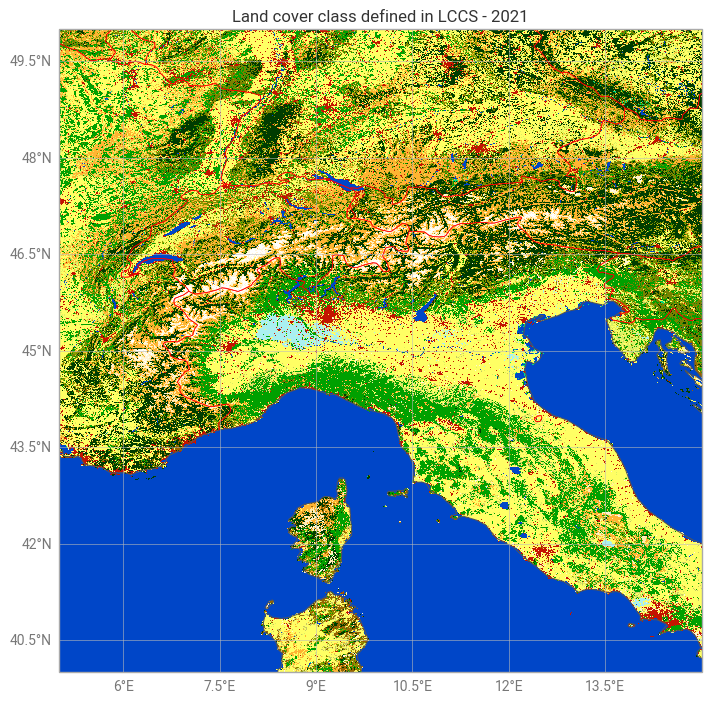

In [12]:
chart = ekp.Map()

chart.grid_cells(lccs_class, style=style)

chart.coastlines()
chart.borders(color="red")
chart.gridlines()

chart.title("{variable_name} - {time:%Y}")

chart.show()